# 17 — Multi-panel figures: `grid`, `facet`, `shared_colorbar`

One map answers one question. Comparison needs several panels that agree on everything except the thing being
compared — same projection, same framing, same colour scale — because any difference a reader can see, they will
read as signal.

`digitalearth.static` has three module-level functions for this. They are functions rather than `Map` methods
precisely because they compose *across* scenes rather than acting on one.

| function | what it does |
|---|---|
| `grid(nrows, ncols, ...)` | builds a figure and axes grid, binds a `Map` to each |
| `facet(stack, ...)` | one panel per item in a stack, drawn for you |
| `shared_colorbar(fig, mappable, maps)` | one colour bar serving every panel |

API: [`Scenes & multi-panel figures`](../reference/static_scene.md).

**Setup**.

In [1]:
%matplotlib inline
from pathlib import Path

import matplotlib.pyplot as plt
from pyramids.dataset import Dataset
from pyramids.feature import FeatureCollection

from digitalearth.static import Map

# The notebook's own folder is the kernel's working directory, so the bundled
# example data sits two levels up: docs/examples -> repo root.
DATA = Path("../../examples/data")


## The data

The Lisbon DEM, plus a small synthetic stack built from it. Scaling one real raster by three factors gives
panels that genuinely differ while staying comparable — the situation faceting exists for.

In [2]:
from pyramids.base.georeference import GeoReference

dem = Dataset.read_file(str(DATA / "LisbonElevation.tif"))
elevation = dem.read_array(band=0).astype("float32")
ref = GeoReference(geo=dem.geotransform, epsg=dem.epsg)
print(f"{dem.rows}x{dem.columns} cells, EPSG:{dem.epsg}")

421x547 cells, EPSG:4326


In [3]:
factors = (1.0, 1.25, 1.5)
stack = [Dataset.from_array(elevation * f, geo_ref=ref) for f in factors]
print(f"{len(stack)} rasters, scaled by {factors}")

3 rasters, scaled by (1.0, 1.25, 1.5)


## `grid` — a figure of maps you fill yourself

`grid` returns `(fig, maps)`: the figure, and a flat list of `Map` objects already bound to each axes. You then
draw whatever you like on each one. Use it when the panels differ in *kind*, not just in data.

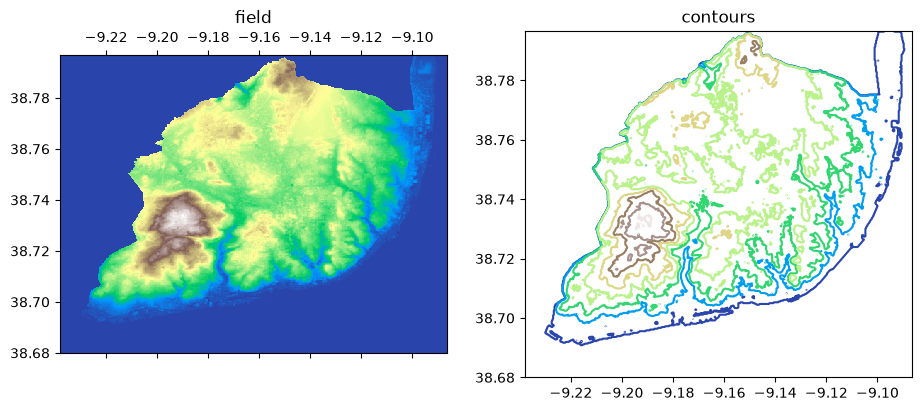

In [4]:
from digitalearth.static import grid

fig, panels = grid(1, 2, crs=dem.epsg, figsize=(11, 4.5))
panels[0].field(dem, cmap="terrain")
panels[0].set_title("field")
panels[1].contours(dem, cmap="terrain")
panels[1].set_title("contours")
fig;

Two different renderings of one raster, sharing a projection and a layout. Because each panel is a full `Map`,
everything from the rest of this gallery works inside it — layers, insets, decoration.

## `sharex` / `sharey` — making panels read as one figure

Shared axes lock the panels' coordinates together, so a feature at the same place appears at the same position in
every panel. Without it, panels with slightly different data extents will subtly misalign.

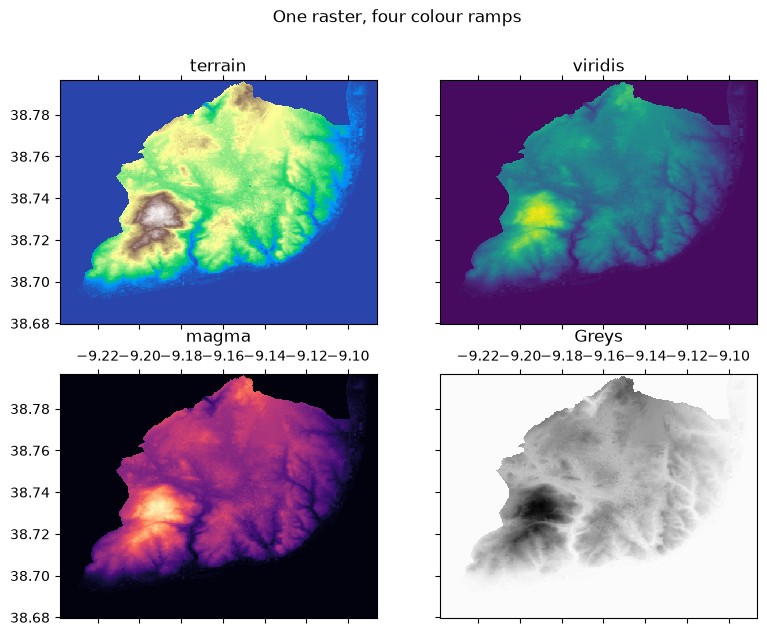

In [5]:
fig, panels = grid(2, 2, crs=dem.epsg, figsize=(9, 7), sharex="all", sharey="all",
                   suptitle="One raster, four colour ramps")
for panel, cmap in zip(panels, ("terrain", "viridis", "magma", "Greys")):
    panel.field(dem, cmap=cmap)
    panel.set_title(cmap)
fig;

`suptitle` names the figure as a whole. Four ramps over identical data is also a useful exercise in itself: the
structure you "see" changes a great deal with the ramp, which is an argument for choosing one deliberately.

## `facet` — one panel per item, drawn for you

Where `grid` gives you empty panels, `facet` takes a **stack** and draws it: one panel per item, same `kind`,
same colour scale, with a colour bar. This is the right tool for a time series or an ensemble.

| argument | meaning | typical value |
|---|---|---|
| `stack` | the rasters to draw, one per panel | a list of `Dataset`, or a collection |
| `labels` | per-panel titles | a sequence as long as the stack |
| `col_wrap` | panels per row before wrapping | an integer |
| `kind` | how each panel is drawn | `"field"` (default), `"contours"`, … |
| `colorbar` | draw the shared bar | `True` (default) |

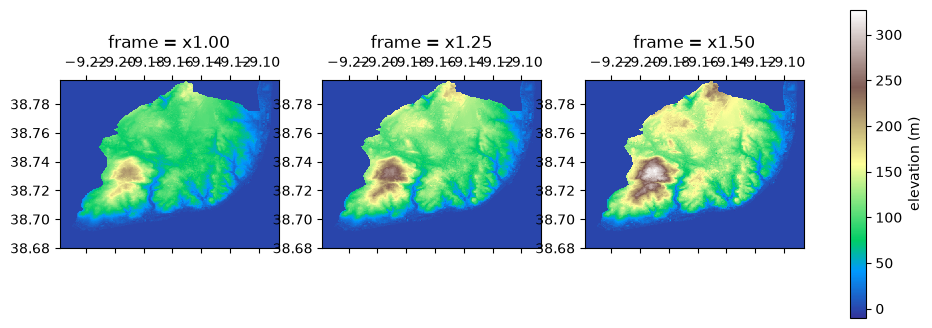

In [6]:
from digitalearth.static import facet

fig, panels = facet(
    stack,
    crs=dem.epsg,
    figsize=(12, 4),
    labels=[f"x{f:.2f}" for f in factors],
    cmap="terrain",
    cbar_label="elevation (m)",
)
fig;

Three panels, one colour scale, one bar. The scale is the critical part: because all three panels share it, the
brightening left to right **is** the 1.0 → 1.5 scaling. Had each panel been normalised to its own range, all
three would look identical and the figure would say nothing — the single most common way a comparison figure
misleads.

## `shared_colorbar` — one bar across panels you built with `grid`

`facet` adds its bar for you. When you built the panels yourself with `grid`, `shared_colorbar` does the same
job: pass the figure, one panel's artist as the mappable, and the panels the bar should span.

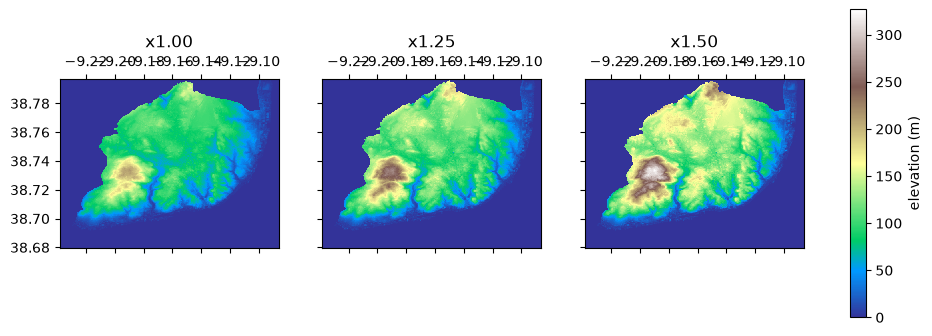

In [7]:
from digitalearth.static import shared_colorbar

fig, panels = grid(1, 3, crs=dem.epsg, figsize=(12, 4), sharey="all")
for panel, raster, f in zip(panels, stack, factors):
    panel.field(raster, cmap="terrain", vmin=0, vmax=float(elevation.max() * 1.5))
    panel.set_title(f"x{f:.2f}")
bar = shared_colorbar(fig, panels[0].artist(), panels, label="elevation (m)")
fig;

Note the `vmin`/`vmax` passed explicitly to every panel. A shared bar is only honest if the panels really do
share a scale — the bar does not impose one, it *reports* one. Pinning the limits is what makes it true, and
leaving them out is how a shared bar ends up lying about panels that were each scaled independently.

## Takeaway

- `grid(nrows, ncols)` → `(fig, maps)`: empty panels you fill, for comparisons across *kinds*.
- `facet(stack)` → one panel per item with a shared scale and bar, for comparisons across *data*.
- `shared_colorbar` adds one bar to panels you built yourself — after pinning `vmin`/`vmax` so the shared scale
  is real.
- `sharex`/`sharey` keep panels aligned; `suptitle` names the whole figure.
- The shared colour scale is the thing that makes a multi-panel figure a comparison instead of a collage.

Next: [`18_global_decorations`](18_global_decorations.ipynb).